In [103]:
import os
import warnings
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, jaccard_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from skimage.feature import graycomatrix, graycoprops

def extract_histogram_features(gray_image, bins=256):
    hist = cv2.calcHist([gray_image], [0], None, [bins], [0, 256])
    hist = hist.flatten()
    hist = hist / hist.sum()
    values = np.arange(bins)
    features = {}
    features['mean'] = np.sum(hist * values)
    variance = np.sum(hist * (values - features['mean']) ** 2)
    features['std'] = np.sqrt(variance)
    if features['std'] > 0:
        features['skewness'] = np.sum(hist * ((values - features['mean']) / features['std']) ** 3)
    else:
        features['skewness'] = 0
    if features['std'] > 0:
        features['kurtosis'] = np.sum(hist * ((values - features['mean']) / features['std']) ** 4) - 3
    else:
        features['kurtosis'] = -3
    non_zero_probs = hist[hist > 0]
    features['entropy'] = -np.sum(non_zero_probs * np.log2(non_zero_probs))
    cumulative_hist = np.cumsum(hist)
    features['q1'] = np.argmax(cumulative_hist >= 0.25)
    features['q2'] = np.argmax(cumulative_hist >= 0.5)
    features['q3'] = np.argmax(cumulative_hist >= 0.75)
    non_zero_bins = np.where(hist > 0)[0]
    if len(non_zero_bins) > 0:
        features['min'] = non_zero_bins[0]
        features['max'] = non_zero_bins[-1]
    else:
        features['min'] = 0
        features['max'] = 255
    return np.array([features['mean'], features['std'], features['skewness'],
                     features['kurtosis'], features['entropy'], features['q1'],
                     features['q2'], features['q3'], features['min'], features['max']])

In [104]:
def laws_texture_features(image, normalize=True):
    L5 = np.array([1, 4, 6, 4, 1])
    E5 = np.array([-1, -2, 0, 2, 1])
    S5 = np.array([-1, 0, 2, 0, -1])
    W5 = np.array([-1, 2, 0, -2, 1])
    R5 = np.array([1, -4, 6, -4, 1])
    masks_1d = [L5, E5, S5, W5, R5]
    filters_2d = []
    for mask1 in masks_1d:
        for mask2 in masks_1d:
            filters_2d.append(np.outer(mask1, mask2))
    features = []
    for kernel in filters_2d:
        filtered = cv2.filter2D(image.astype(np.float32), -1, kernel)
        features.append(np.mean(filtered ** 2))
    features = np.array(features)
    if normalize and np.sum(features) > 0:
        features = features / np.sum(features)
    return features
     
def compute_glcm_features(image, distances=[1], angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]):
    image = (image // 8).astype(np.uint8)
    glcm = graycomatrix(image, distances=distances, angles=angles,
                        levels=32, symmetric=True, normed=True)
    features = []
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']

    for prop in props:
        features.append(np.mean(graycoprops(glcm, prop)))

    return np.array(features), props

In [105]:
def segment_image(model_info, model_name, image, patch_size=8, step=4, n_classes=4):
    h, w = image.shape
    seg_map = np.zeros((h, w), dtype=np.uint8)
    all_predictions = []

    for y in range(0, h - patch_size + 1, step):
        for x in range(0, w - patch_size + 1, step):
            patch = image[y:y + patch_size, x:x + patch_size]

            if 'Histogram' in model_name:
                features = extract_histogram_features(patch)
            elif 'Laws' in model_name:
                features = laws_texture_features(patch)
            elif 'GLCM' in model_name:
                features, _ = compute_glcm_features(patch)

            if isinstance(model_info, tuple):
                model, scaler = model_info
                features_scaled = scaler.transform(features.reshape(1, -1))
                pred_class = model.predict(features_scaled)[0]
            else:
                model = model_info
                pred_class = model.predict(features.reshape(1, -1))[0]

            seg_map[y:y + patch_size, x:x + patch_size] = pred_class
            all_predictions.append(pred_class)

    unique, counts = np.unique(all_predictions, return_counts=True)
    top_classes = unique[np.argsort(counts)[-n_classes:]]
    seg_map_filtered = np.zeros_like(seg_map)

    for i, class_id in enumerate(top_classes):
        seg_map_filtered[seg_map == class_id] = i

    mask_not_in_top = ~np.isin(seg_map, top_classes)
    if np.any(mask_not_in_top):
        seg_map_filtered[mask_not_in_top] = 1

    return seg_map_filtered

In [106]:
def create_manual_mask(image, n_regions=4):
    h, w = image.shape
    block_size = 16
    blocks_h = h // block_size
    blocks_w = w // block_size
    block_features = []
    block_positions = []

    for i in range(blocks_h):
        for j in range(blocks_w):
            block = image[i * block_size:min((i + 1) * block_size, h),
            j * block_size:min((j + 1) * block_size, w)]
            block_features.append([np.mean(block), np.std(block)])
            block_positions.append((i, j))

    kmeans = KMeans(n_clusters=n_regions, random_state=42, n_init=10)
    block_labels = kmeans.fit_predict(block_features)
    manual_mask = np.zeros((h, w), dtype=np.uint8)

    for (i, j), label in zip(block_positions, block_labels):
        manual_mask[i * block_size:min((i + 1) * block_size, h),
        j * block_size:min((j + 1) * block_size, w)] = label

    return manual_mask

In [107]:
def compare_masks(manual_mask, predicted_mask, model_name):
    if manual_mask.shape != predicted_mask.shape:
        predicted_mask = cv2.resize(predicted_mask, (manual_mask.shape[1], manual_mask.shape[0]),
                                    interpolation=cv2.INTER_NEAREST)

    class_mapping = {}
    for pred_class in np.unique(predicted_mask):
        best_overlap = -1
        for manual_class in np.unique(manual_mask):
            overlap = np.sum((manual_mask == manual_class) & (predicted_mask == pred_class))
            if overlap > best_overlap:
                best_overlap = overlap
                class_mapping[pred_class] = manual_class

    pred_mapped = predicted_mask.copy()
    for pred_class, manual_class in class_mapping.items():
        pred_mapped[predicted_mask == pred_class] = manual_class

    accuracy = accuracy_score(manual_mask.flatten(), pred_mapped.flatten())
    iou_scores = []

    for class_id in np.unique(manual_mask):
        iou = jaccard_score(manual_mask.flatten(), pred_mapped.flatten(),
                            average=None, labels=[class_id])[0]
        iou_scores.append(iou)

    mean_iou = np.mean(iou_scores)

    # Вывод точности и IoU по классам в формате как в примере
    print(f"\nТочность: {accuracy * 100:.1f}%")
    print("Предсказание по классам:")
    for i, iou in enumerate(iou_scores):
        print(f"  Класс {i}: {iou:.3f}")

    return accuracy, mean_iou, iou_scores, pred_mapped

In [108]:
def compute_histogram(gray_image, bins=256):
    hist = cv2.calcHist([gray_image], [0], None, [bins], [0, 256])
    hist = hist.flatten()
    hist = hist / hist.sum()

    values = np.arange(bins)
    features = {}

    features['mean'] = np.sum(hist * values)

    variance = np.sum(hist * (values - features['mean']) ** 2)
    features['std'] = np.sqrt(variance)

    if features['std'] > 0:
        features['skewness'] = np.sum(hist * ((values - features['mean']) / features['std']) ** 3)
    else:
        features['skewness'] = 0

    if features['std'] > 0:
        features['kurtosis'] = np.sum(hist * ((values - features['mean']) / features['std']) ** 4) - 3
    else:
        features['kurtosis'] = -3

    non_zero_probs = hist[hist > 0]
    features['entropy'] = -np.sum(non_zero_probs * np.log2(non_zero_probs))

    cumulative_hist = np.cumsum(hist)
    features['q1'] = np.argmax(cumulative_hist >= 0.25)
    features['q2'] = np.argmax(cumulative_hist >= 0.5)
    features['q3'] = np.argmax(cumulative_hist >= 0.75)

    non_zero_bins = np.where(hist > 0)[0]
    if len(non_zero_bins) > 0:
        features['min'] = non_zero_bins[0]
        features['max'] = non_zero_bins[-1]
    else:
        features['min'] = 0
        features['max'] = 255

    return features, hist

In [109]:
def laws_texture_features_with_names(image, normalize=True):
    L5 = np.array([1, 4, 6, 4, 1])
    E5 = np.array([-1, -2, 0, 2, 1])
    S5 = np.array([-1, 0, 2, 0, -1])
    W5 = np.array([-1, 2, 0, -2, 1])
    R5 = np.array([1, -4, 6, -4, 1])

    masks_1d = [L5, E5, S5, W5, R5]
    masks_names = ['L5', 'E5', 'S5', 'W5', 'R5']

    filters_2d = []
    filter_names = []

    for i, mask1 in enumerate(masks_1d):
        for j, mask2 in enumerate(masks_1d):
            kernel = np.outer(mask1, mask2)
            filters_2d.append(kernel)
            filter_names.append(f"{masks_names[i]}{masks_names[j]}")

    features = []
    feature_names = []

    for kernel, name in zip(filters_2d, filter_names):
        filtered = cv2.filter2D(image.astype(np.float32), -1, kernel)
        energy = np.mean(filtered ** 2)
        features.append(energy)
        feature_names.append(f"laws_{name}")

    features = np.array(features)

    if normalize and np.sum(features) > 0:
        features = features / np.sum(features)

    return features, feature_names
     

ГРАФИЧЕСКИЙ АНАЛИЗ ТЕКСТУРНЫХ ХАРАКТЕРИСТИК

1. Графики гистограмм для текстур:


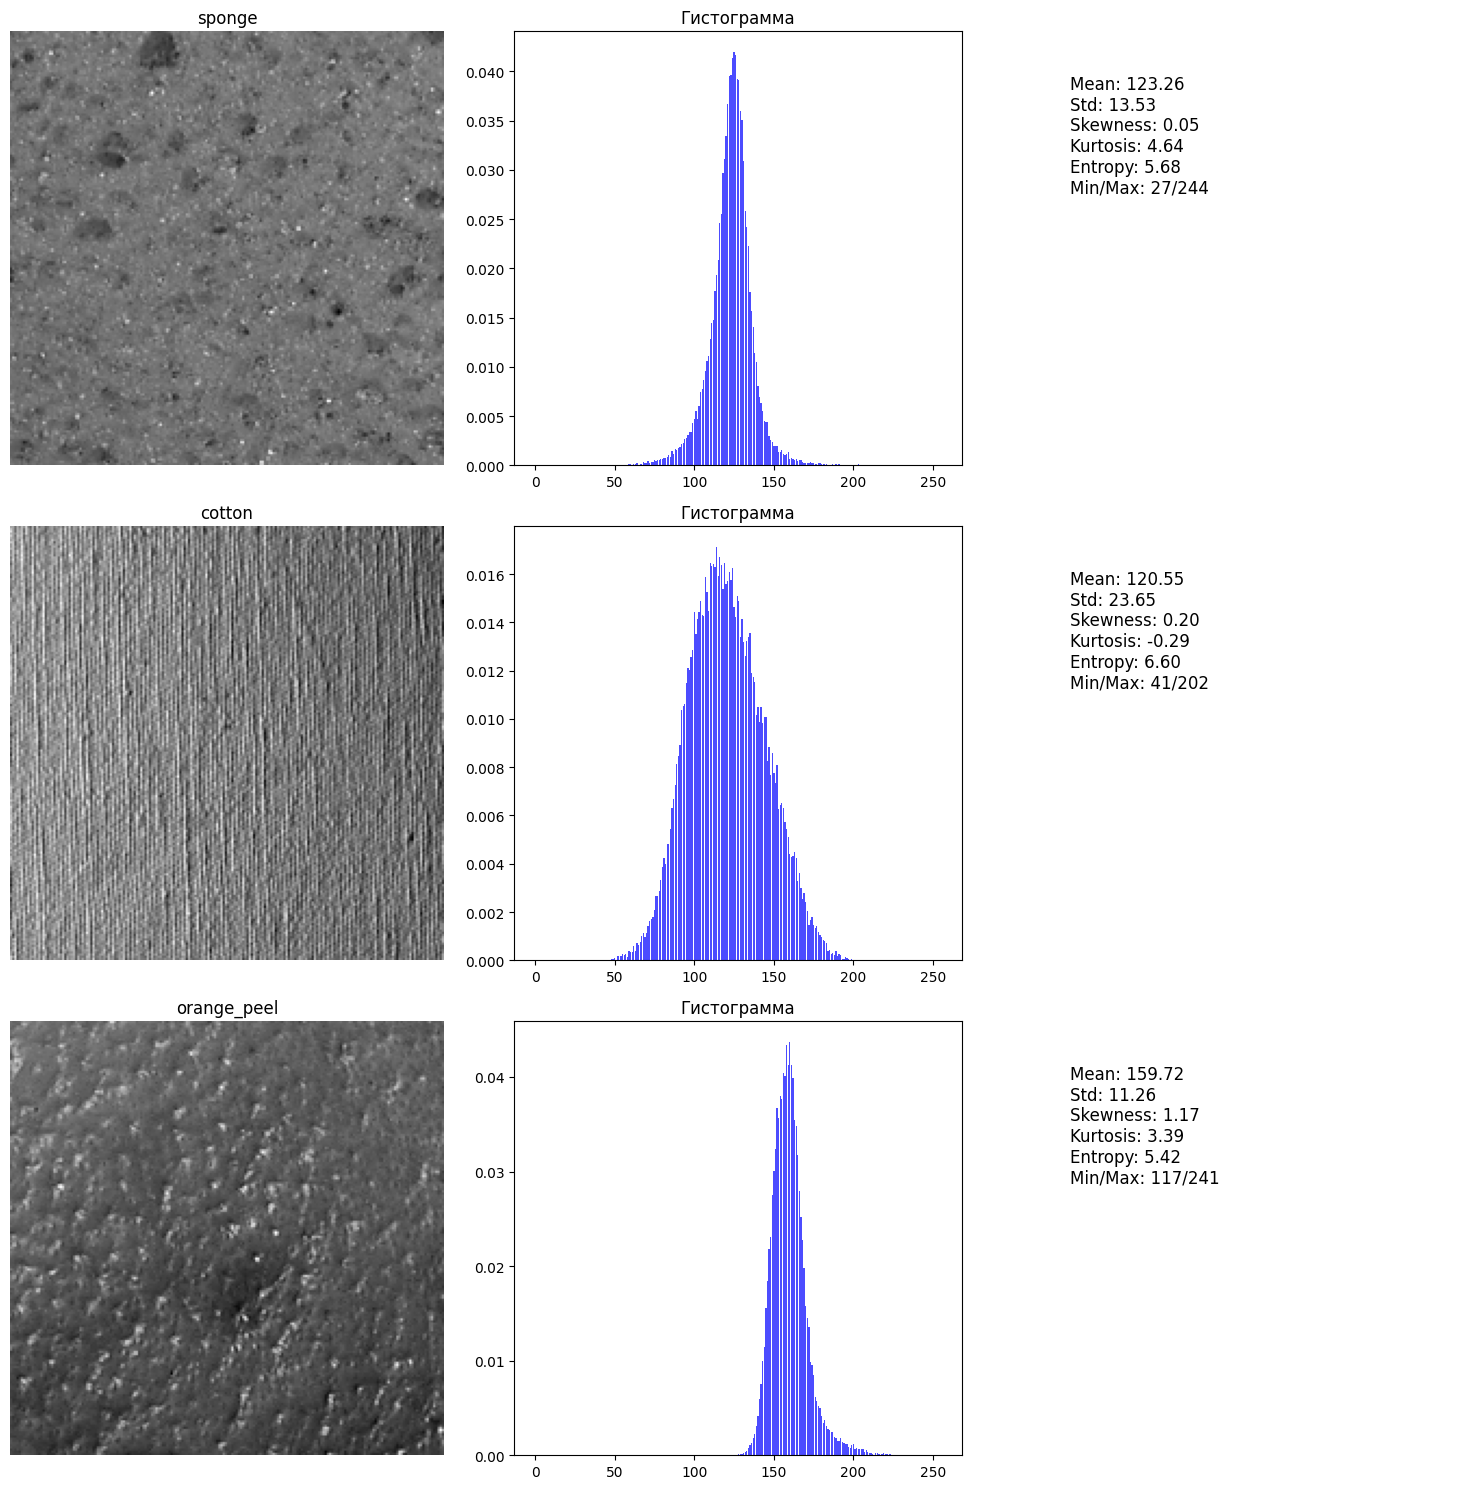


2. Графики Laws текстур:


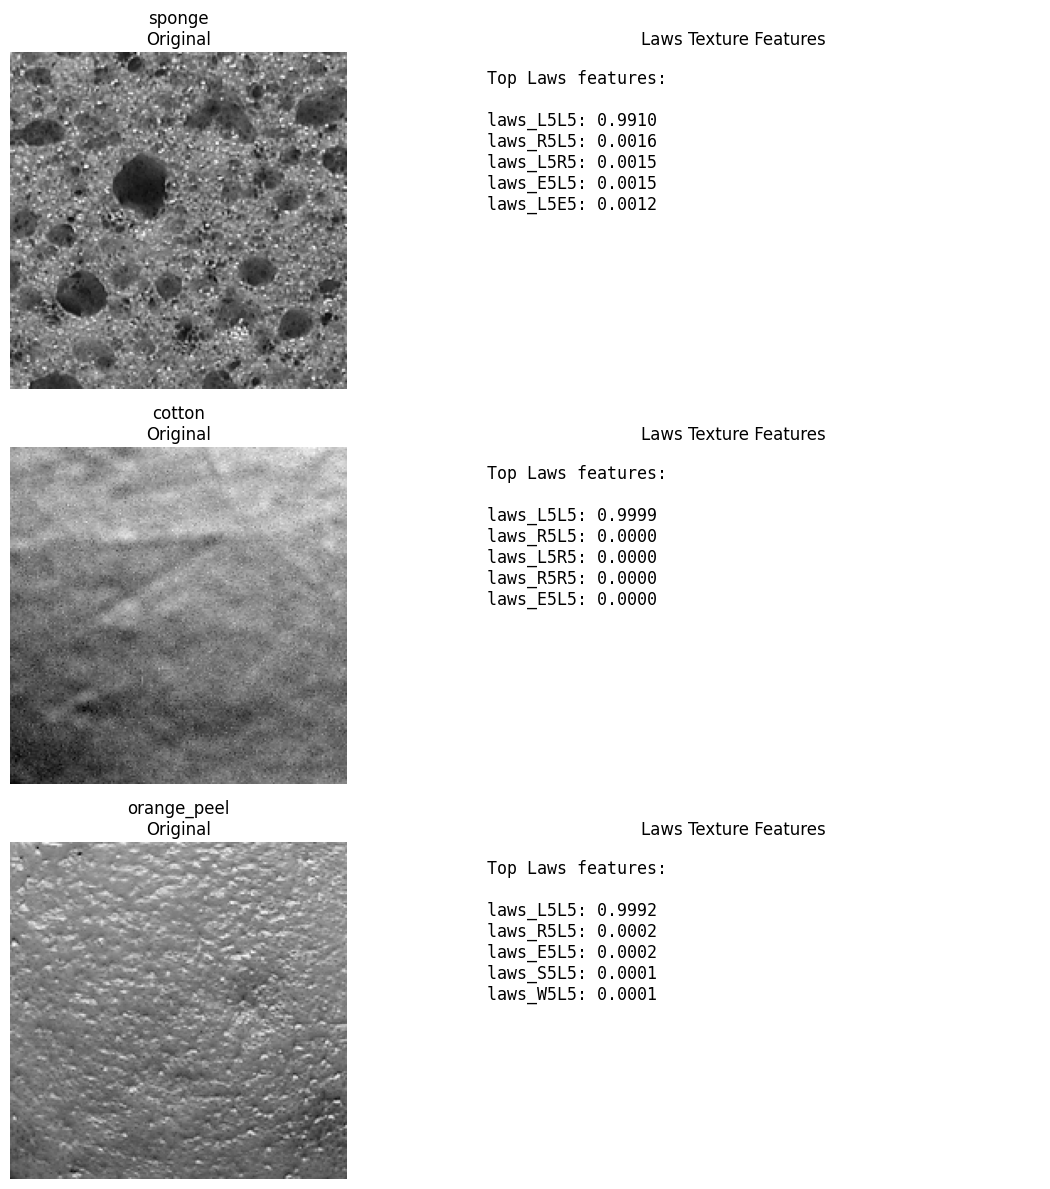


3. Графики GLCM характеристик:


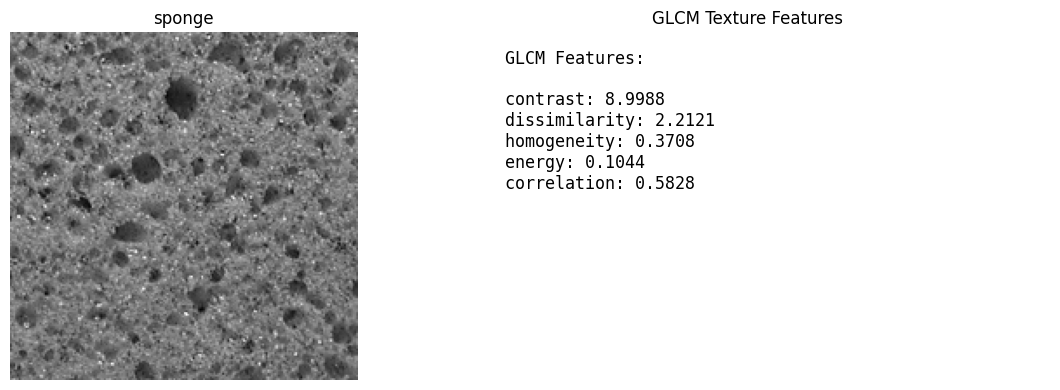

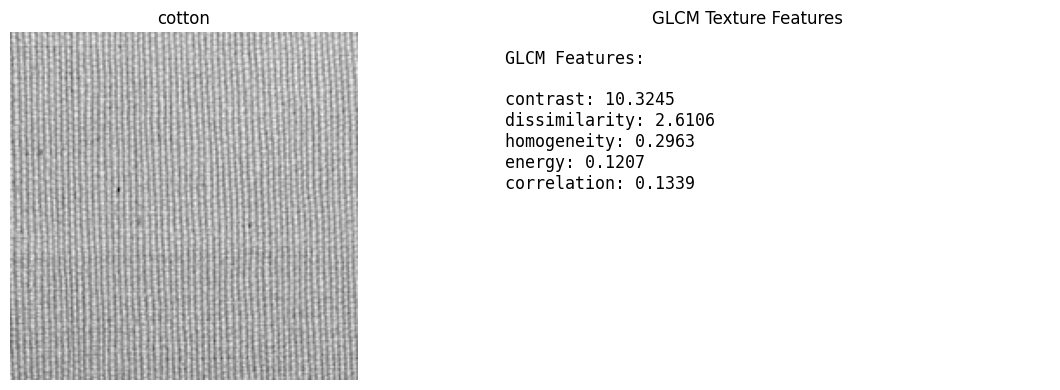

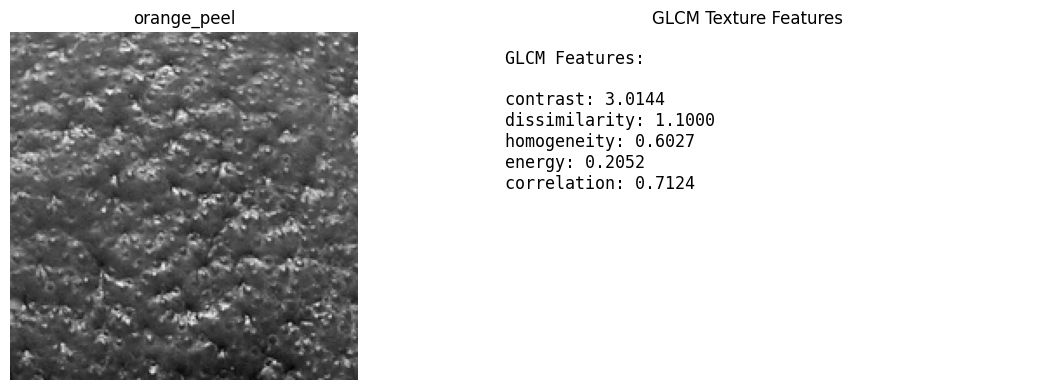


ТЕКСТУРНЫЙ АНАЛИЗ ТЕСТОВОГО ИЗОБРАЖЕНИЯ

Анализ изображения: test_image.jpg
Размер изображения: (165, 305)

GLCM характеристики:
----------------------------------------
contrast: 5.7111
dissimilarity: 1.4984
homogeneity: 0.5383
energy: 0.1033
correlation: 0.9578

Гистограммные характеристики:
----------------------------------------
mean: 100.24
std: 65.80
skewness: 0.05
kurtosis: -1.40
entropy: 7.70
q1: 36.00
q2: 99.00
q3: 162.00
min: 0.00
max: 246.00

Laws текстуры (первые 5 самых важных):
----------------------------------------
Фильтр 0: 0.9955
Фильтр 5: 0.0013
Фильтр 20: 0.0007
Фильтр 1: 0.0006
Фильтр 4: 0.0005

СЕГМЕНТАЦИЯ ИЗОБРАЖЕНИЯ РАЗНЫМИ МОДЕЛЯМИ

   Обрабатываем: Histogram_KNN
   Уникальные классы после фильтрации: [0 1 2 3]

Точность: 58.7%
Предсказание по классам:
  Класс 0: 0.000
  Класс 1: 0.243
  Класс 2: 0.512
  Класс 3: 0.641

   Обрабатываем: Laws_SVM
   Уникальные классы после фильтрации: [0 1 2 3]

Точность: 43.1%
Предсказание по классам:
  Класс 0: 0.272
  Клас

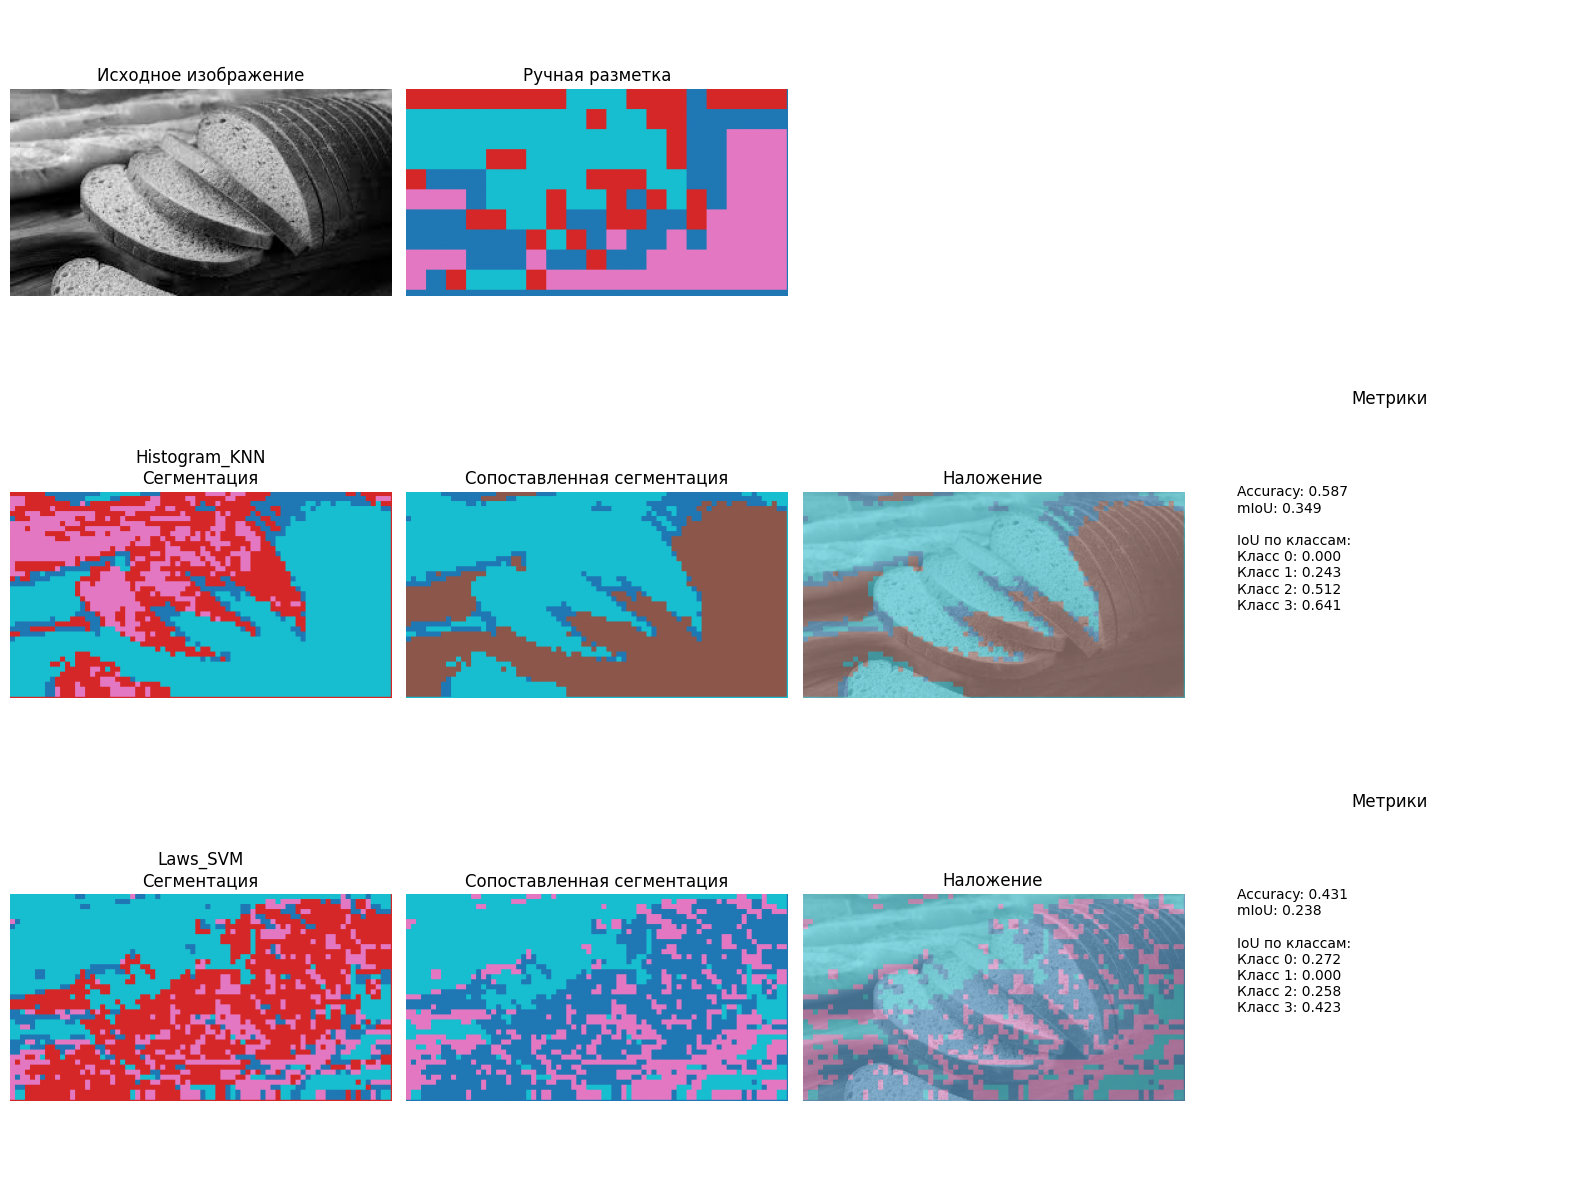


СВОДНЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ СЕГМЕНТАЦИИ:

Модель               Accuracy     mIoU         IoU по классам                
----------------------------------------------------------------------
Histogram_KNN        0.587        0.349        0.000, 0.243, 0.512, 0.641
Laws_SVM             0.431        0.238        0.272, 0.000, 0.258, 0.423
GLCM_Tree            0.409        0.222        0.000, 0.190, 0.420, 0.277

Ручная маска сохранена как 'manual_mask.jpg'
Результаты сравнения сохранены как 'segmentation_comparison.jpg'


In [110]:
if __name__ == "__main__":
    image_folder = "./KTH_TIPS"
    image_paths = []

    for class_folder in os.listdir(image_folder):
        class_path = os.path.join(image_folder, class_folder)
        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(class_path, file))

    X_hist, X_laws, X_glcm, y = [], [], [], []

    for path in image_paths:
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image is not None:
            image = cv2.resize(image, (128, 128), interpolation=cv2.INTER_AREA)
            X_hist.append(extract_histogram_features(image))
            X_laws.append(laws_texture_features(image))
            glcm_features, _ = compute_glcm_features(image)
            X_glcm.append(glcm_features)
            y.append(os.path.basename(os.path.dirname(path)))

    X_hist, X_laws, X_glcm = np.array(X_hist), np.array(X_laws), np.array(X_glcm)
    y = np.array(y)

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    methods = {'Histogram': X_hist, 'Laws': X_laws, 'GLCM': X_glcm}
    trained_models = {}

    for method_name, X in methods.items():
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
        )

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        method_models = {}

        # KNN
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_train, y_train)
        method_models['KNN'] = knn

        # SVM
        svm = SVC(kernel='rbf', random_state=42)
        svm.fit(X_train_scaled, y_train)
        method_models['SVM'] = (svm, scaler)

        # Decision Tree
        tree = DecisionTreeClassifier(random_state=42, max_depth=10)
        tree.fit(X_train, y_train)
        method_models['DecisionTree'] = tree

        trained_models[method_name] = method_models

    print("=" * 60)
    print("ГРАФИЧЕСКИЙ АНАЛИЗ ТЕКСТУРНЫХ ХАРАКТЕРИСТИК")
    print("=" * 60)

    def example_plot_texture(image_folder, num_examples=3):
        texture_folders = [f for f in os.listdir(image_folder) if os.path.isdir(os.path.join(image_folder, f))]

        fig, axes = plt.subplots(num_examples, 3, figsize=(15, 5 * num_examples))

        for i in range(min(num_examples, len(texture_folders))):
            texture_name = texture_folders[i]
            texture_path = os.path.join(image_folder, texture_name)

            image_files = [f for f in os.listdir(texture_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            if len(image_files) > 3:
                image_path = os.path.join(texture_path, image_files[3])
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                if image is not None:
                    features, hist = compute_histogram(image)

                    axes[i, 0].imshow(image, cmap='gray')
                    axes[i, 0].set_title(f'{texture_name}')
                    axes[i, 0].axis('off')

                    axes[i, 1].bar(range(256), hist, alpha=0.7, color='blue')
                    axes[i, 1].set_title('Гистограмма')

                    metrics_text = (
                        f"Mean: {features['mean']:.2f}\n"
                        f"Std: {features['std']:.2f}\n"
                        f"Skewness: {features['skewness']:.2f}\n"
                        f"Kurtosis: {features['kurtosis']:.2f}\n"
                        f"Entropy: {features['entropy']:.2f}\n"
                        f"Min/Max: {features['min']}/{features['max']}"
                    )

                    axes[i, 2].text(0.1, 0.9, metrics_text, transform=axes[i, 2].transAxes, fontsize=12,
                                    verticalalignment='top')
                    axes[i, 2].axis('off')

        plt.tight_layout()
        plt.show()

    def example_plot_laws(image_folder, num_examples=3):
        texture_folders = [f for f in os.listdir(image_folder) if os.path.isdir(os.path.join(image_folder, f))]

        fig, axes = plt.subplots(num_examples, 2, figsize=(12, 4 * num_examples))

        for i in range(min(num_examples, len(texture_folders))):
            texture_name = texture_folders[i]
            texture_path = os.path.join(image_folder, texture_name)

            image_files = [f for f in os.listdir(texture_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            if len(image_files) > 5:
                image_path = os.path.join(texture_path, image_files[5])
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                if image is not None:
                    features, names = laws_texture_features_with_names(image)

                    axes[i, 0].imshow(image, cmap='gray')
                    axes[i, 0].set_title(f'{texture_name}\nOriginal')
                    axes[i, 0].axis('off')

                    top_indices = np.argsort(features)[-5:][::-1]
                    laws_text = "Top Laws features:\n\n"
                    for j, idx in enumerate(top_indices):
                        laws_text += f"{names[idx]}: {features[idx]:.4f}\n"

                    axes[i, 1].text(0.1, 0.95, laws_text, transform=axes[i, 1].transAxes,
                                    fontsize=12, verticalalignment='top', fontfamily='monospace')
                    axes[i, 1].set_title('Laws Texture Features')
                    axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

    def example_plot_glcm(image_folder, num_examples=3):
        texture_folders = [f for f in os.listdir(image_folder) if os.path.isdir(os.path.join(image_folder, f))]

        for i in range(min(num_examples, len(texture_folders))):
            texture_name = texture_folders[i]
            texture_path = os.path.join(image_folder, texture_name)

            image_files = [f for f in os.listdir(texture_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            if len(image_files) > 2:
                image_path = os.path.join(texture_path, image_files[2])
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                if image is not None:
                    features, props = compute_glcm_features(image)

                    plt.figure(figsize=(12, 4))

                    plt.subplot(1, 2, 1)
                    plt.imshow(image, cmap='gray')
                    plt.title(f'{texture_name}')
                    plt.axis('off')

                    plt.subplot(1, 2, 2)

                    glcm_text = "GLCM Features:\n\n"
                    for name, value in zip(props, features):
                        glcm_text += f"{name}: {value:.4f}\n"

                    plt.text(0.1, 0.95, glcm_text, transform=plt.gca().transAxes,
                            fontsize=12, verticalalignment='top', fontfamily='monospace')
                    plt.axis('off')
                    plt.title('GLCM Texture Features')

                    plt.tight_layout()
                    plt.show()

    print("\n1. Графики гистограмм для текстур:")
    example_plot_texture(image_folder, num_examples=3)

    print("\n2. Графики Laws текстур:")
    example_plot_laws(image_folder, num_examples=3)

    print("\n3. Графики GLCM характеристик:")
    example_plot_glcm(image_folder, num_examples=3)

    print("\n" + "=" * 60)
    print("ТЕКСТУРНЫЙ АНАЛИЗ ТЕСТОВОГО ИЗОБРАЖЕНИЯ")
    print("=" * 60)

    test_image_path = "test_image.jpg"
    test_image = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

    if test_image is not None:
        print(f"\nАнализ изображения: {test_image_path}")
        print(f"Размер изображения: {test_image.shape}")

        glcm_features, prop_names = compute_glcm_features(test_image)
        print("\nGLCM характеристики:")
        print("-" * 40)
        for name, value in zip(prop_names, glcm_features):
            print(f"{name}: {value:.4f}")

        hist_features = extract_histogram_features(test_image)
        print("\nГистограммные характеристики:")
        print("-" * 40)
        hist_feature_names = ['mean', 'std', 'skewness', 'kurtosis', 'entropy',
                              'q1', 'q2', 'q3', 'min', 'max']
        for name, value in zip(hist_feature_names, hist_features):
            print(f"{name}: {value:.2f}")

        laws_features = laws_texture_features(test_image)
        print("\nLaws текстуры (первые 5 самых важных):")
        print("-" * 40)
        top_indices = np.argsort(laws_features)[-5:][::-1]
        for idx in top_indices:
            print(f"Фильтр {idx}: {laws_features[idx]:.4f}")

    original_test_image = test_image

    if original_test_image is not None:
        manual_mask = create_manual_mask(original_test_image, n_regions=4)
        cv2.imwrite("manual_mask.png", manual_mask * 63)

        selected_models = {
            'Histogram_KNN': trained_models['Histogram']['KNN'],
            'Histogram_SVM': trained_models['Histogram']['SVM'],
            'Histogram_Tree': trained_models['Histogram']['DecisionTree'],
            'Laws_KNN': trained_models['Laws']['KNN'],
            'Laws_SVM': trained_models['Laws']['SVM'],
            'Laws_Tree': trained_models['Laws']['DecisionTree'],
            'GLCM_KNN': trained_models['GLCM']['KNN'],
            'GLCM_SVM': trained_models['GLCM']['SVM'],
            'GLCM_Tree': trained_models['GLCM']['DecisionTree']
        }

        results = {}

        comparison_models = ['Histogram_KNN', 'Laws_SVM', 'GLCM_Tree']

        print("\n" + "=" * 60)
        print("СЕГМЕНТАЦИЯ ИЗОБРАЖЕНИЯ РАЗНЫМИ МОДЕЛЯМИ")
        print("=" * 60)

        for model_name in comparison_models:
            print(f"\n   Обрабатываем: {model_name}")

            model_info = selected_models[model_name]
            predicted_mask = segment_image(model_info, model_name, original_test_image)

            if predicted_mask is not None:
                print(f"   Уникальные классы после фильтрации: {np.unique(predicted_mask)}")

                # Сравнение масок
                accuracy, mean_iou, iou_scores, pred_mapped = compare_masks(
                    manual_mask, predicted_mask, model_name
                )
                results[model_name] = {
                    'accuracy': accuracy,
                    'mean_iou': mean_iou,
                    'iou_scores': iou_scores
                }
            else:
                print(f"   Ошибка сегментации")

        fig, axes = plt.subplots(3, 4, figsize=(16, 12))

        axes[0, 0].imshow(original_test_image, cmap='gray')
        axes[0, 0].set_title('Исходное изображение')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(manual_mask, cmap='tab10')
        axes[0, 1].set_title('Ручная разметка')
        axes[0, 1].axis('off')

        axes[0, 2].axis('off')
        axes[0, 3].axis('off')

        model_name = 'Histogram_KNN'
        model_info = selected_models[model_name]
        predicted_mask = segment_image(model_info, model_name, original_test_image)
        accuracy, mean_iou, iou_scores, pred_mapped = compare_masks(
            manual_mask, predicted_mask, model_name
        )

        axes[1, 0].imshow(predicted_mask, cmap='tab10')
        axes[1, 0].set_title(f'{model_name}\nСегментация')
        axes[1, 0].axis('off')

        axes[1, 1].imshow(pred_mapped, cmap='tab10')
        axes[1, 1].set_title('Сопоставленная сегментация')
        axes[1, 1].axis('off')

        axes[1, 2].imshow(original_test_image, cmap='gray', alpha=0.6)
        axes[1, 2].imshow(pred_mapped, cmap='tab10', alpha=0.5)
        axes[1, 2].set_title('Наложение')
        axes[1, 2].axis('off')

        # Метрики для Histogram_KNN
        axes[1, 3].text(0.1, 0.8, f'Accuracy: {accuracy:.3f}\nmIoU: {mean_iou:.3f}\n\nIoU по классам:\n' +
                        '\n'.join([f'Класс {i}: {iou:.3f}' for i, iou in enumerate(iou_scores)]),
                        transform=axes[1, 3].transAxes, verticalalignment='top')
        axes[1, 3].set_title('Метрики')
        axes[1, 3].axis('off')

        model_name = 'Laws_SVM'
        model_info = selected_models[model_name]
        predicted_mask = segment_image(model_info, model_name, original_test_image)
        accuracy, mean_iou, iou_scores, pred_mapped = compare_masks(
            manual_mask, predicted_mask, model_name
        )

        axes[2, 0].imshow(predicted_mask, cmap='tab10')
        axes[2, 0].set_title(f'{model_name}\nСегментация')
        axes[2, 0].axis('off')

        axes[2, 1].imshow(pred_mapped, cmap='tab10')
        axes[2, 1].set_title('Сопоставленная сегментация')
        axes[2, 1].axis('off')

        axes[2, 2].imshow(original_test_image, cmap='gray', alpha=0.6)
        axes[2, 2].imshow(pred_mapped, cmap='tab10', alpha=0.5)
        axes[2, 2].set_title('Наложение')
        axes[2, 2].axis('off')

        axes[2, 3].text(0.1, 0.8, f'Accuracy: {accuracy:.3f}\nmIoU: {mean_iou:.3f}\n\nIoU по классам:\n' +
                        '\n'.join([f'Класс {i}: {iou:.3f}' for i, iou in enumerate(iou_scores)]),
                        transform=axes[2, 3].transAxes, verticalalignment='top')
        axes[2, 3].set_title('Метрики')
        axes[2, 3].axis('off')

        plt.tight_layout()
        plt.savefig('segmentation_comparison.jpg', dpi=150, bbox_inches='tight')
        plt.show()

        print("\n" + "=" * 60)
        print("СВОДНЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ СЕГМЕНТАЦИИ:")
        print("=" * 60)

        print(f"\n{'Модель':<20} {'Accuracy':<12} {'mIoU':<12} {'IoU по классам':<30}")
        print("-" * 70)

        for model_name in comparison_models:
            metrics = results[model_name]
            iou_str = ', '.join([f'{iou:.3f}' for iou in metrics['iou_scores']])
            print(f"{model_name:<20} {metrics['accuracy']:.3f}        {metrics['mean_iou']:.3f}        {iou_str}")

        print("\nРучная маска сохранена как 'manual_mask.jpg'")
        print("Результаты сравнения сохранены как 'segmentation_comparison.jpg'")

    else:
        print(f"Не удалось загрузить тестовое изображение: test_image.jpg")